In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)

# Load the data
df = pd.read_csv('../data/processed/macro_data.csv')

# Date to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


# Lag features for GDP 
gdp_lag_periods = [1, 2, 3, 4, 8]
for lag in gdp_lag_periods:
    df[f'GDP_lag_{lag}'] = df['GDP'].shift(lag)

# Moving averages for GDP
window_sizes = [2, 4, 8]
for window in window_sizes:
    df[f'GDP_MA_{window}'] = df['GDP'].rolling(window=window).mean()

# Rate of change features
for col in ['Inflation', 'Unemployment', 'CurrentAccount']:
    df[f'{col}_ROC'] = df[col].pct_change()

# Lag features for other variables
other_vars = ['Inflation', 'Unemployment', 'CurrentAccount', 'Exports', 'Imports']
other_lag_periods = [1, 2, 4]
for feature in other_vars:
    for lag in other_lag_periods:
        df[f'{feature}_lag_{lag}'] = df[feature].shift(lag)

# Trade balance and ratio features
df['TradeBalance'] = df['Exports'] - df['Imports']
df['TradeRatio'] = df['Exports'] / df['Imports']
df['TradeBalance_to_GDP'] = df['TradeBalance'] / df['GDP'].replace(0, np.nan).fillna(0.001)

# Interaction terms
df['Inflation_Unemployment'] = df['Inflation'] * df['Unemployment']
df['TradeBalance_CurrentAccount'] = df['TradeBalance'] * df['CurrentAccount']

# Year and quarter features
df['Year'] = df.index.year
df['Quarter'] = df.index.quarter
df['YearQuarter'] = df['Year'] + df['Quarter'] / 10

# Quarterly growth rates
for col in ['Exports', 'Imports']:
    df[f'{col}_QGrowth'] = df[col].pct_change()

# Remove rows with NaN values
df_processed = df.dropna()


print(f"Number of features after engineering: {df_processed.shape[1] - 1}")

# Split features and target
X = df_processed.drop('GDP', axis=1)
y = df_processed['GDP']


n = len(df_processed)
train_idx = int(n * 0.7)
val_idx = int(n * 0.85)

# Split the data
X_train = X.iloc[:train_idx]
y_train = y.iloc[:train_idx]

X_val = X.iloc[train_idx:val_idx]
y_val = y.iloc[train_idx:val_idx]

X_test = X.iloc[val_idx:]
y_test = y.iloc[val_idx:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Calculate mean baseline performance
y_mean = np.mean(y_train)
y_pred_mean = np.full_like(y_test, y_mean)
mean_baseline_mse = mean_squared_error(y_test, y_pred_mean)
mean_baseline_r2 = r2_score(y_test, y_pred_mean)
print(f"Mean baseline MSE: {mean_baseline_mse:.6f}")
print(f"Mean baseline R²: {mean_baseline_r2:.6f}")

# Define parameters directly
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.005,
    'max_depth': 2,
    'min_child_weight': 2,
    'subsample': 0.7,        # More aggressive subsampling
    'colsample_bytree': 0.8,
    'n_estimators': 500,     # More trees with slower learning rate
    'reg_alpha': 0.1,        # L1 regularization
    'reg_lambda': 1.0,       # L2 regularization
    'random_state': 42
}

# Train model
model = xgb.XGBRegressor(**params)

# Create eval set for validation
eval_set = [(X_train_scaled, y_train), (X_val_scaled, y_val)]

# Train on training data
model.fit(
    X_train_scaled,
    y_train,
    eval_set=eval_set,
    verbose=False
)

# Make predictions on test set
y_pred = model.predict(X_test_scaled)

# Evalate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nImproved XGBoost Model Performance on Test Set:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


# Save the model
#model.save_model('xgboost_gdp_model_improved.json')

Number of features after engineering: 41
Training set: 58 samples
Validation set: 13 samples
Test set: 13 samples
Mean baseline MSE: 0.071598
Mean baseline R²: -0.000004

Improved XGBoost Model Performance on Test Set:
MSE: 0.0474
RMSE: 0.2176
MAE: 0.1969
R²: 0.3386


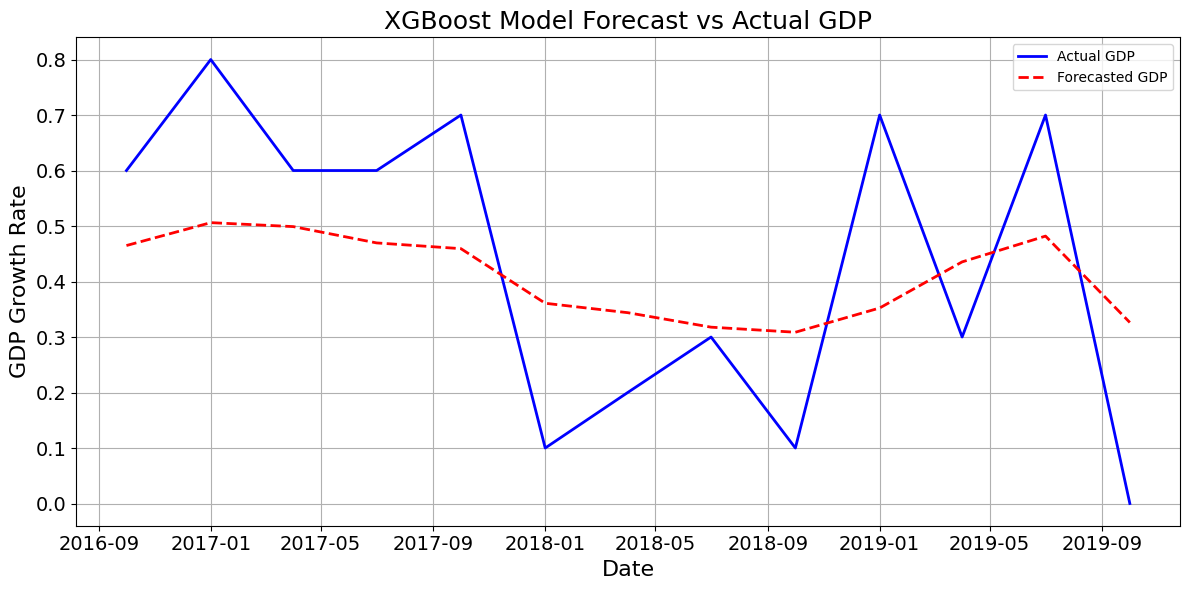

In [5]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual GDP', color='blue', linewidth=2)
plt.plot(y_test.index, y_pred, label='Forecasted GDP', color='red', linestyle='--', linewidth=2)

plt.title('XGBoost Model Forecast vs Actual GDP', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('GDP Growth Rate', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

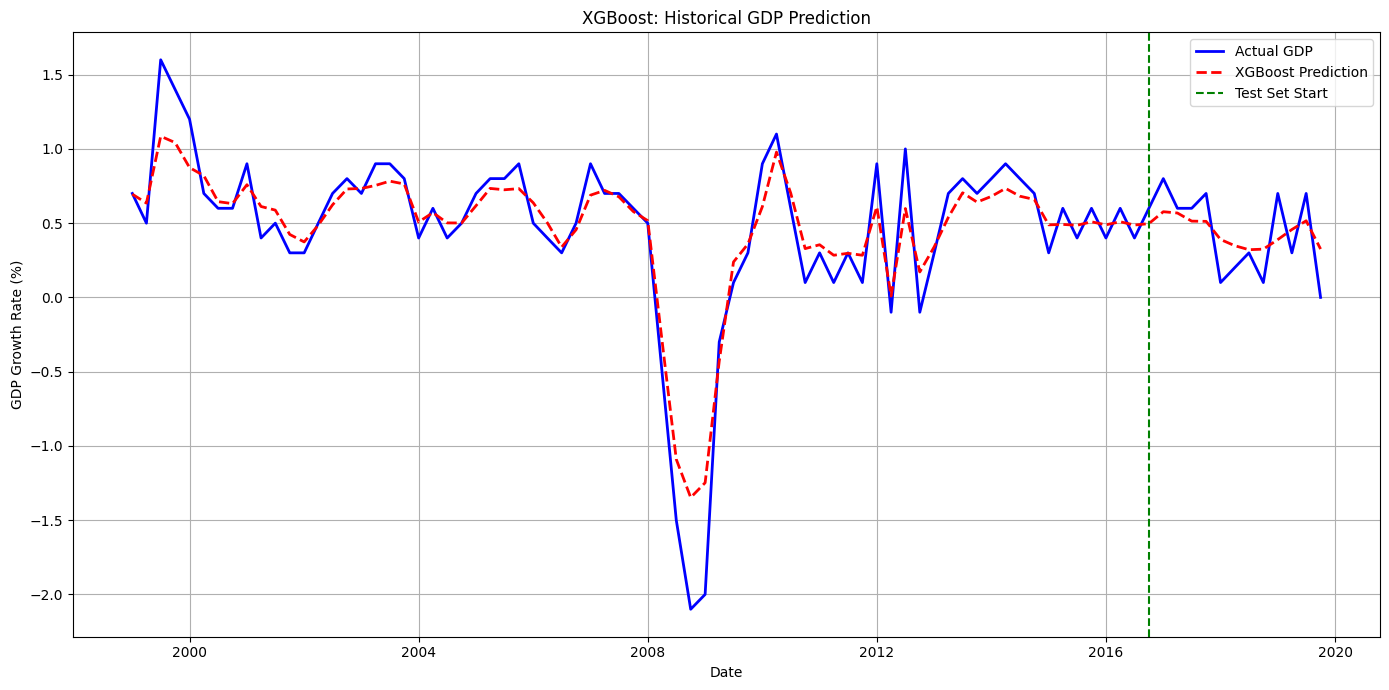

In [6]:
# Plot historical prediction
# Train a model on all data except the test set
full_model = xgb.XGBRegressor(**params)
X_not_test = pd.concat([X_train, X_val])
y_not_test = pd.concat([y_train, y_val])
X_not_test_scaled = scaler.transform(X_not_test)
full_model.fit(X_not_test_scaled, y_not_test)

# Get all prediction points
all_X_scaled = scaler.transform(X)
all_preds = full_model.predict(all_X_scaled)

# Plot all historical data with predictions
plt.figure(figsize=(14, 7))
plt.plot(df_processed.index, df_processed['GDP'], 'b-', label='Actual GDP', linewidth=2)
plt.plot(df_processed.index, all_preds, 'r--', label='XGBoost Prediction', linewidth=2)
plt.axvline(x=y_test.index[0], color='g', linestyle='--', label='Test Set Start')
plt.title('XGBoost: Historical GDP Prediction')
plt.xlabel('Date')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('xgboost_historical_predictions.png')
plt.show()

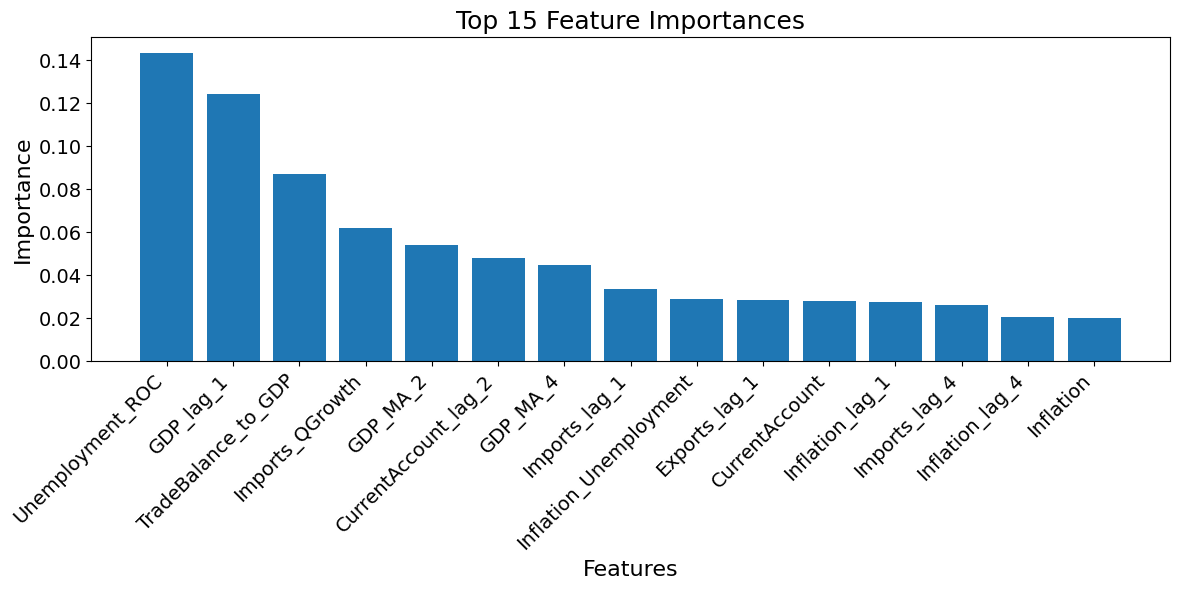

In [2]:
plt.figure(figsize=(12, 6))
importance = model.feature_importances_
top_idx = np.argsort(importance)[::-1][:15]
plt.bar(range(15), importance[top_idx])
plt.xticks(range(15), np.array(X.columns)[top_idx], rotation=45, ha='right')
plt.title("Top 15 Feature Importances", fontsize=18)
plt.ylabel("Importance", fontsize=16)
plt.xlabel("Features", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


In [3]:
# Save results for comparison
xgb_forecast_df = pd.DataFrame({
    'Date': y_test.index,
    'Actual_GDP': y_test.values,
    'XGBoost_Forecast': y_pred
})

# Save to CSV
#xgb_forecast_df.to_csv('xgboost_forecast_results.csv', index=False)


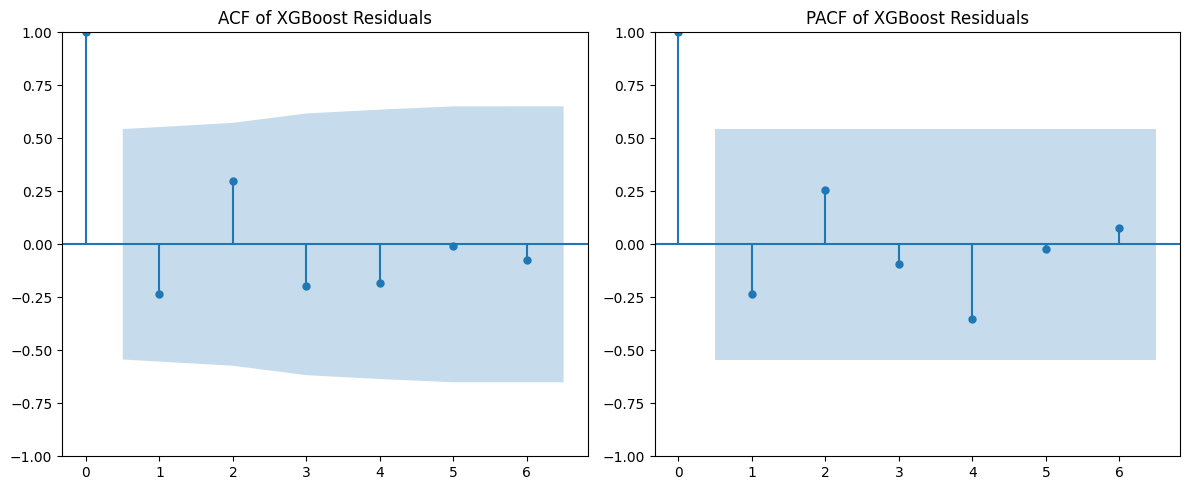

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


residuals = np.array(residuals).flatten()
residuals = residuals[~np.isnan(residuals)]
max_lags = min(20, len(residuals) // 2)

# Plot ACF and PACF
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_acf(residuals, ax=plt.gca(), lags=max_lags)
plt.title('ACF of XGBoost Residuals')

plt.subplot(1, 2, 2)
plot_pacf(residuals, ax=plt.gca(), lags=max_lags, method='ywm')
plt.title('PACF of XGBoost Residuals')

plt.tight_layout()
plt.show()
